In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [14]:
df = pd.read_csv('Battery_RUL.csv')
df.head()

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [15]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15064 entries, 0 to 15063
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Cycle_Index                15064 non-null  float64
 1   Discharge Time (s)         15064 non-null  float64
 2   Decrement 3.6-3.4V (s)     15064 non-null  float64
 3   Max. Voltage Dischar. (V)  15064 non-null  float64
 4   Min. Voltage Charg. (V)    15064 non-null  float64
 5   Time at 4.15V (s)          15064 non-null  float64
 6   Time constant current (s)  15064 non-null  float64
 7   Charging time (s)          15064 non-null  float64
 8   RUL                        15064 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.0 MB


Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64

In [16]:
# Using IQR to remove outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Filter out the outliers
df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]


In [17]:
# Example: Convert RUL into 3 categories
def classify_rul(rul):
    if rul > 1000:
        return 'High'
    elif rul > 500:
        return 'Medium'
    else:
        return 'Low'

df['RUL_Class'] = df['RUL'].apply(classify_rul)


In [18]:
X = df.drop(['RUL', 'RUL_Class'], axis=1)
y = df['RUL_Class']


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Convert 'High', 'Medium', 'Low' to 0,1,2


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


KNN Accuracy: 0.9875389408099688
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       266
           1       1.00      0.99      0.99      1321
           2       0.99      0.99      0.99      1302

    accuracy                           0.99      2889
   macro avg       0.98      0.98      0.98      2889
weighted avg       0.99      0.99      0.99      2889



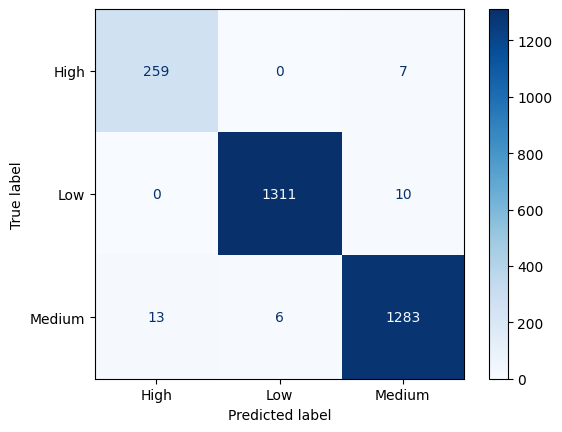

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')


In [26]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9965385946694358
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       266
           1       1.00      1.00      1.00      1321
           2       1.00      0.99      1.00      1302

    accuracy                           1.00      2889
   macro avg       0.99      1.00      0.99      2889
weighted avg       1.00      1.00      1.00      2889



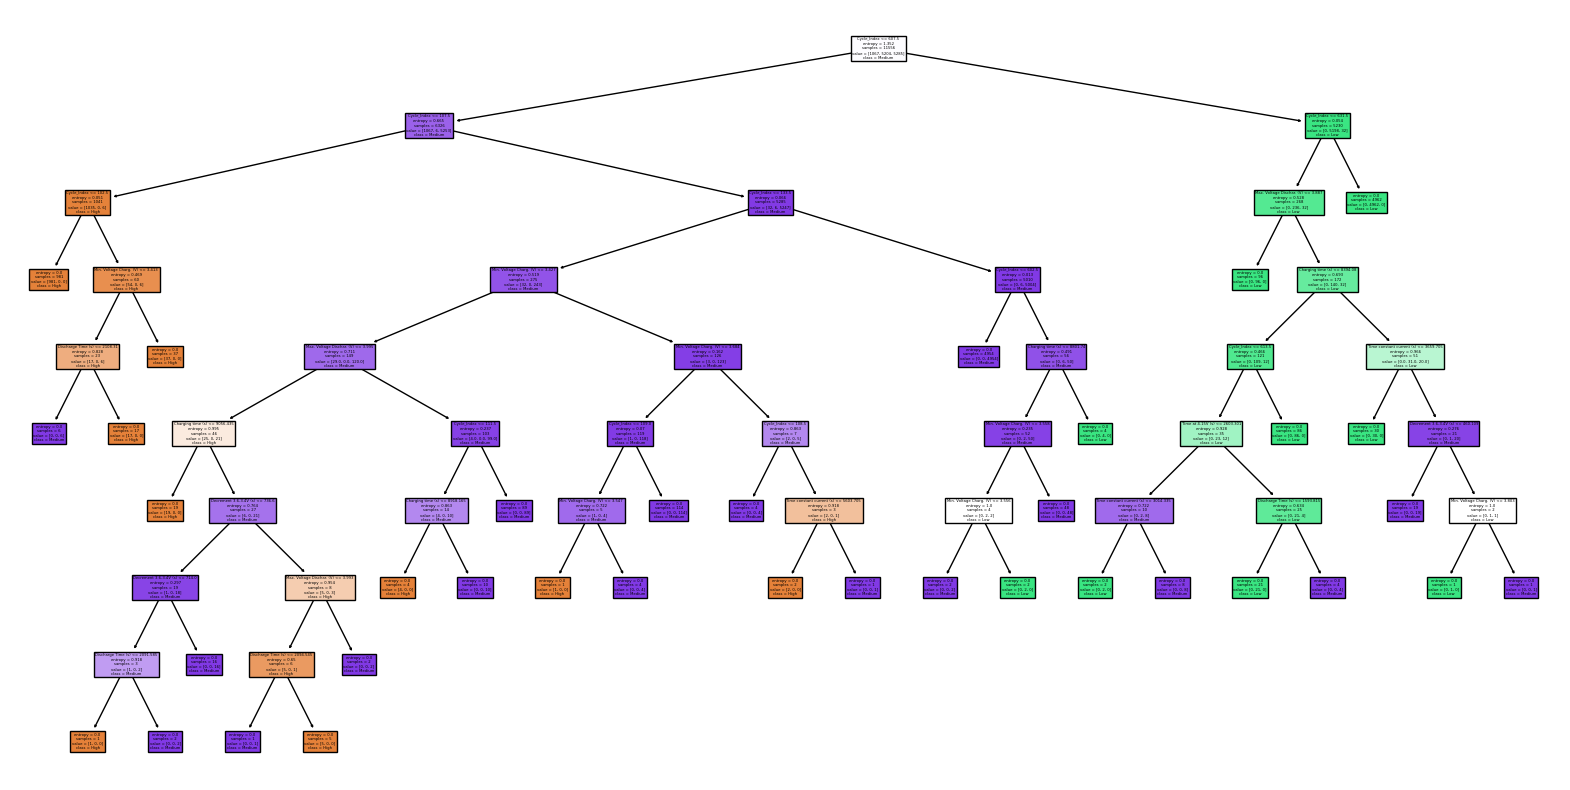

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=le.classes_)
plt.show()


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Pruned Decision Tree
new_pruned_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,              # Limit the depth to avoid overfitting
    min_samples_leaf=15,        # Minimum samples required at a leaf node
    random_state=42
)

new_pruned_tree.fit(X_train, y_train)
y_pred_pruned = new_pruned_tree.predict(X_test)

# Evaluation
print("Pruned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))
print(classification_report(y_test, y_pred_pruned))


Pruned Decision Tree Accuracy: 0.9951540325372101
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       266
           1       1.00      1.00      1.00      1321
           2       1.00      0.99      0.99      1302

    accuracy                           1.00      2889
   macro avg       0.99      1.00      0.99      2889
weighted avg       1.00      1.00      1.00      2889



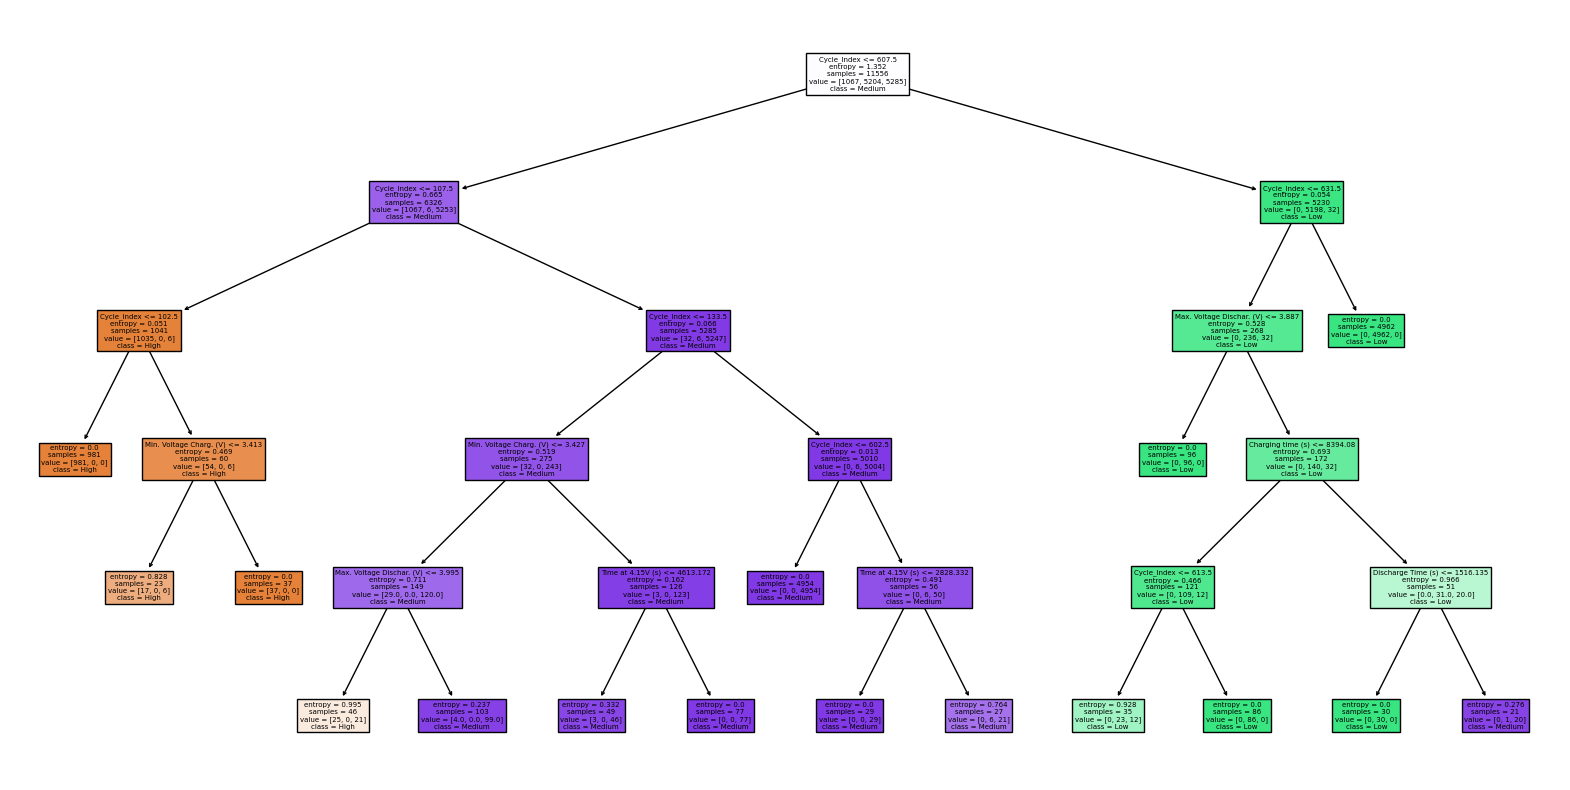

In [34]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(new_pruned_tree, filled=True, feature_names=X.columns, class_names=le.classes_)
plt.show()
